In [10]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../outputs/figures")
TAB_DIR = Path("../outputs/tables")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
df = pl.read_parquet("../data/cleaned/model_features.parquet").to_pandas()

print("Shape:", df.shape)
df.head()

Shape: (1088, 42)


,game_id,season,week,gameday,team,opponent,points_for,points_against,rest_days,is_home,...,opp_rolling_points_for_3,opp_rolling_points_against_3,opp_rolling_win_pct_3,opp_rolling_off_epa_3,opp_rolling_turnovers_3,opp_rolling_point_diff_3,epa_diff_3,win_pct_diff_3,turnover_diff_3,point_diff_gap_3
0,2024_01_ARI_BUF,2024,1,2024-09-08,ARI,BUF,28,34,7,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024_02_LA_ARI,2024,2,2024-09-15,ARI,LA,41,10,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024_03_DET_ARI,2024,3,2024-09-22,ARI,DET,13,20,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024_04_WAS_ARI,2024,4,2024-09-29,ARI,WAS,14,42,7,1,...,26.333333,29.333333,0.666667,0.264153,0.000000,-3.000000,-0.206900,-0.333333,1.000000,9.0
4,2024_05_ARI_SF,2024,5,2024-10-06,ARI,SF,24,23,7,0,...,23.666667,21.000000,0.333333,0.086459,1.333333,2.666667,-0.079055,0.000000,-0.333333,-4.0


In [12]:
print(df.columns.tolist())
print(df.dtypes)

['game_id', 'season', 'week', 'gameday', 'team', 'opponent', 'points_for', 'points_against', 'rest_days', 'is_home', 'win', 'offensive_plays', 'off_epa_per_play', 'pass_plays', 'rush_plays', 'interceptions_thrown', 'fumbles_lost', 'pass_rate', 'turnovers', 'point_diff', 'prev_points_for', 'prev_points_against', 'prev_win', 'prev_off_epa_per_play', 'prev_turnovers', 'prev_point_diff', 'rolling_points_for_3', 'rolling_points_against_3', 'rolling_win_pct_3', 'rolling_off_epa_3', 'rolling_turnovers_3', 'rolling_point_diff_3', 'opp_rolling_points_for_3', 'opp_rolling_points_against_3', 'opp_rolling_win_pct_3', 'opp_rolling_off_epa_3', 'opp_rolling_turnovers_3', 'opp_rolling_point_diff_3', 'epa_diff_3', 'win_pct_diff_3', 'turnover_diff_3', 'point_diff_gap_3']
game_id                                    str
season                                   int32
week                                     int32
gameday                         datetime64[ms]
team                                       str
o

In [13]:
summary_cols = [
    "win",
    "is_home",
    "rest_days",
    "rolling_win_pct_3",
    "opp_rolling_win_pct_3",
    "win_pct_diff_3",
    "rolling_off_epa_3",
    "opp_rolling_off_epa_3",
    "epa_diff_3",
    "rolling_point_diff_3",
    "opp_rolling_point_diff_3",
    "point_diff_gap_3"
]

summary_stats = df[summary_cols].describe()
summary_stats.to_csv(TAB_DIR / "summary_stats.csv")
summary_stats

,win,is_home,rest_days,rolling_win_pct_3,opp_rolling_win_pct_3,win_pct_diff_3,rolling_off_epa_3,opp_rolling_off_epa_3,epa_diff_3,rolling_point_diff_3,opp_rolling_point_diff_3,point_diff_gap_3
count,1088.000000,1088.00000,1088.000000,992.000000,992.000000,9.920000e+02,992.000000,992.000000,9.920000e+02,9.920000e+02,9.920000e+02,9.920000e+02
mean,0.499081,0.50000,7.419118,0.498992,0.498992,3.581365e-18,0.007207,0.007207,-3.581365e-18,5.730183e-17,-2.865092e-17,5.730183e-17
std,0.500229,0.50023,2.049723,0.331815,0.331815,4.714045e-01,0.142067,0.142067,2.018015e-01,9.518619e+00,9.518619e+00,1.352287e+01
min,0.000000,0.00000,4.000000,0.000000,0.000000,-1.000000e+00,-0.441536,-0.441536,-7.000069e-01,-2.766667e+01,-2.766667e+01,-4.066667e+01
25%,0.000000,0.00000,7.000000,0.333333,0.333333,-3.333333e-01,-0.089957,-0.089957,-1.371627e-01,-7.000000e+00,-7.000000e+00,-9.000000e+00
50%,0.000000,0.50000,7.000000,0.333333,0.333333,0.000000e+00,0.014932,0.014932,0.000000e+00,3.333333e-01,3.333333e-01,0.000000e+00
75%,1.000000,1.00000,7.000000,0.666667,0.666667,3.333333e-01,0.106279,0.106279,1.371627e-01,6.666667e+00,6.666667e+00,9.000000e+00
max,1.000000,1.00000,15.000000,1.000000,1.000000,1.000000e+00,0.424420,0.424420,7.000069e-01,2.600000e+01,2.600000e+01,4.066667e+01


In [14]:
missingness = df.isna().sum().sort_values(ascending=False).reset_index()
missingness.columns = ["column", "missing_count"]
missingness["missing_pct"] = missingness["missing_count"] / len(df)

missingness.to_csv(TAB_DIR / "missingness_summary.csv", index=False)
missingness.head(20)

,column,missing_count,missing_pct
0,point_diff_gap_3,96,0.088235
1,opp_rolling_points_against_3,96,0.088235
2,rolling_points_for_3,96,0.088235
3,rolling_points_against_3,96,0.088235
4,rolling_win_pct_3,96,0.088235
5,rolling_off_epa_3,96,0.088235
6,rolling_turnovers_3,96,0.088235
7,rolling_point_diff_3,96,0.088235
8,opp_rolling_points_for_3,96,0.088235
9,opp_rolling_win_pct_3,96,0.088235


In [15]:
eda = df.dropna(subset=[
    "win_pct_diff_3",
    "rolling_win_pct_3",
    "opp_rolling_win_pct_3",
    "epa_diff_3",
    "rolling_point_diff_3",
    "opp_rolling_point_diff_3",
    "point_diff_gap_3"
]).copy()

print("EDA shape:", eda.shape)

EDA shape: (992, 42)


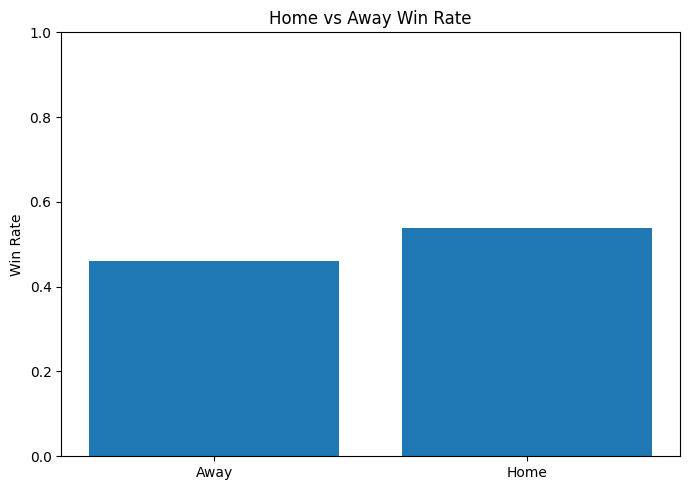

,is_home,win,location
0,0,0.459677,Away
1,1,0.538306,Home


In [16]:
home_away = eda.groupby("is_home")["win"].mean().reset_index()
home_away["location"] = home_away["is_home"].map({0: "Away", 1: "Home"})

plt.figure(figsize=(7, 5))
plt.bar(home_away["location"], home_away["win"])
plt.ylabel("Win Rate")
plt.title("Home vs Away Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "home_vs_away_win_rate.png", dpi=300, bbox_inches="tight")
plt.show()

home_away.to_csv(TAB_DIR / "home_away_win_rate.csv", index=False)
home_away

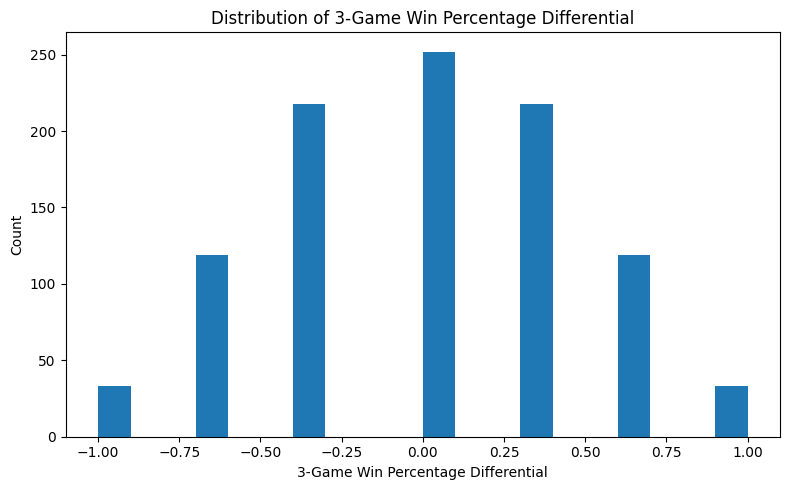

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(eda["win_pct_diff_3"], bins=20)
plt.xlabel("3-Game Win Percentage Differential")
plt.ylabel("Count")
plt.title("Distribution of 3-Game Win Percentage Differential")
plt.tight_layout()
plt.savefig(FIG_DIR / "distribution_win_pct_diff_3.png", dpi=300, bbox_inches="tight")
plt.show()

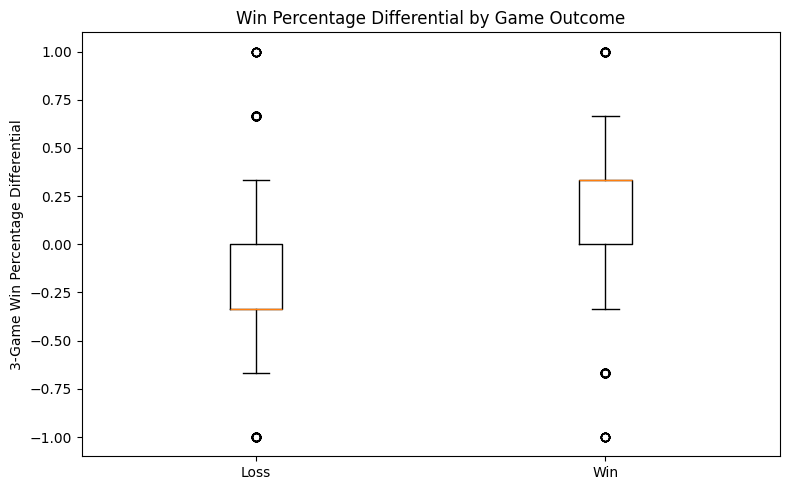

,outcome,mean_win_pct_diff_3,median_win_pct_diff_3
0,Loss,-0.146211,-0.333333
1,Win,0.146801,0.333333


In [18]:
losses = eda.loc[eda["win"] == 0, "win_pct_diff_3"]
wins = eda.loc[eda["win"] == 1, "win_pct_diff_3"]

plt.figure(figsize=(8, 5))
plt.boxplot([losses, wins], tick_labels=["Loss", "Win"])
plt.ylabel("3-Game Win Percentage Differential")
plt.title("Win Percentage Differential by Game Outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "win_pct_diff_by_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

win_pct_outcome_summary = pd.DataFrame({
    "outcome": ["Loss", "Win"],
    "mean_win_pct_diff_3": [losses.mean(), wins.mean()],
    "median_win_pct_diff_3": [losses.median(), wins.median()]
})

win_pct_outcome_summary.to_csv(TAB_DIR / "win_pct_diff_outcome_summary.csv", index=False)
win_pct_outcome_summary

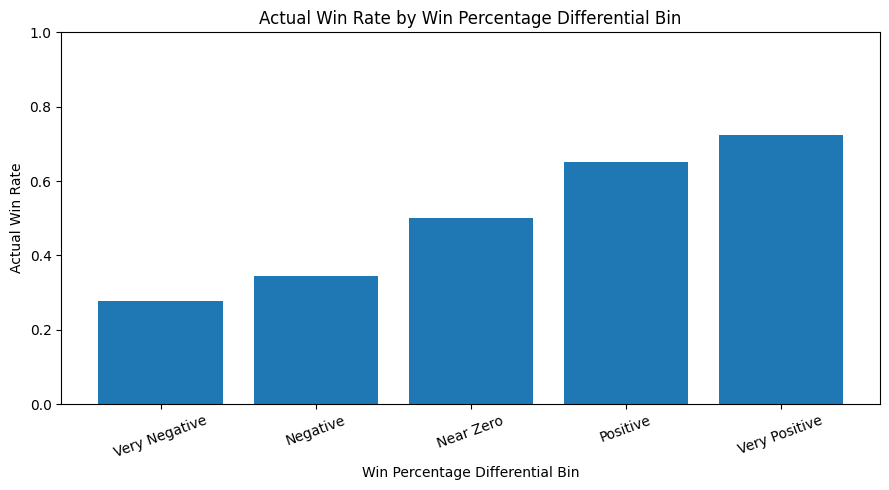

,win_pct_bin,win_rate,n_games
0,Very Negative,0.276316,152
1,Negative,0.344037,218
2,Near Zero,0.500000,252
3,Positive,0.651376,218
4,Very Positive,0.723684,152


In [19]:
eda["win_pct_bin"] = pd.cut(
    eda["win_pct_diff_3"],
    bins=[-1.01, -0.5, -0.1, 0.1, 0.5, 1.01],
    labels=["Very Negative", "Negative", "Near Zero", "Positive", "Very Positive"]
)

bin_summary = eda.groupby("win_pct_bin", observed=False)["win"].agg(["mean", "count"]).reset_index()
bin_summary.columns = ["win_pct_bin", "win_rate", "n_games"]

plt.figure(figsize=(9, 5))
plt.bar(bin_summary["win_pct_bin"].astype(str), bin_summary["win_rate"])
plt.ylabel("Actual Win Rate")
plt.xlabel("Win Percentage Differential Bin")
plt.title("Actual Win Rate by Win Percentage Differential Bin")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "win_rate_by_win_pct_bin.png", dpi=300, bbox_inches="tight")
plt.show()

bin_summary.to_csv(TAB_DIR / "win_pct_bin_summary.csv", index=False)
bin_summary

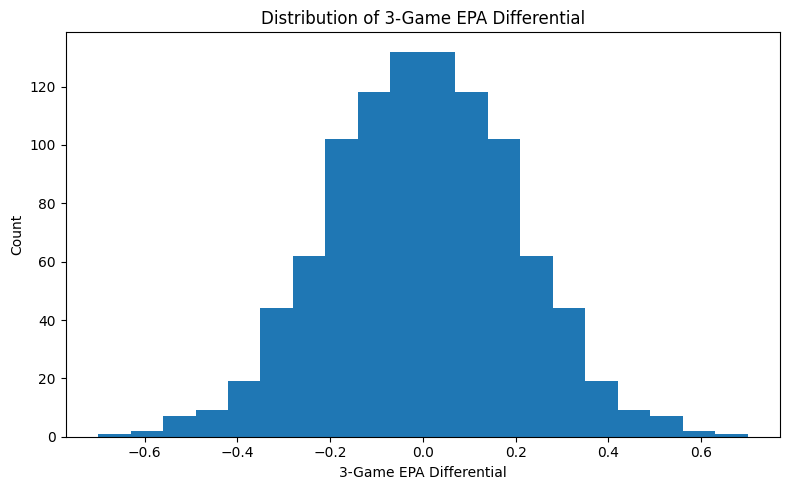

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(eda["epa_diff_3"], bins=20)
plt.xlabel("3-Game EPA Differential")
plt.ylabel("Count")
plt.title("Distribution of 3-Game EPA Differential")
plt.tight_layout()
plt.savefig(FIG_DIR / "distribution_epa_diff_3.png", dpi=300, bbox_inches="tight")
plt.show()

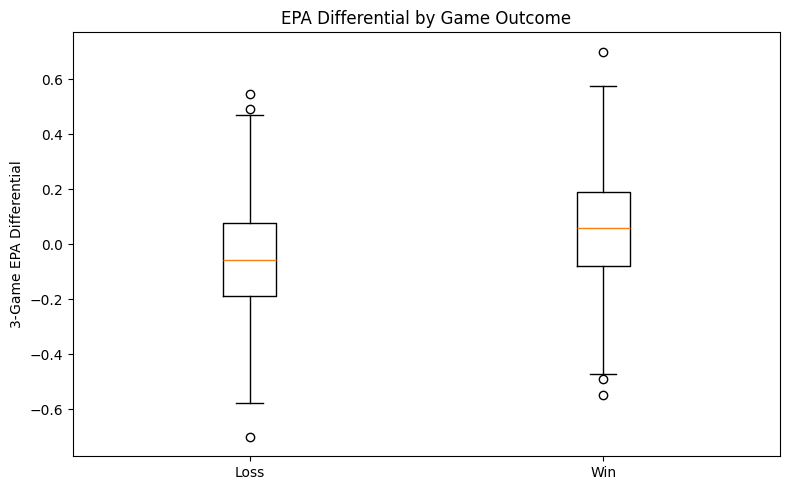

,outcome,mean_epa_diff_3,median_epa_diff_3
0,Loss,-0.057112,-0.058784
1,Win,0.057343,0.059347


In [21]:
epa_losses = eda.loc[eda["win"] == 0, "epa_diff_3"]
epa_wins = eda.loc[eda["win"] == 1, "epa_diff_3"]

plt.figure(figsize=(8, 5))
plt.boxplot([epa_losses, epa_wins], tick_labels=["Loss", "Win"])
plt.ylabel("3-Game EPA Differential")
plt.title("EPA Differential by Game Outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "epa_diff_by_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

epa_outcome_summary = pd.DataFrame({
    "outcome": ["Loss", "Win"],
    "mean_epa_diff_3": [epa_losses.mean(), epa_wins.mean()],
    "median_epa_diff_3": [epa_losses.median(), epa_wins.median()]
})

epa_outcome_summary.to_csv(TAB_DIR / "epa_diff_outcome_summary.csv", index=False)
epa_outcome_summary

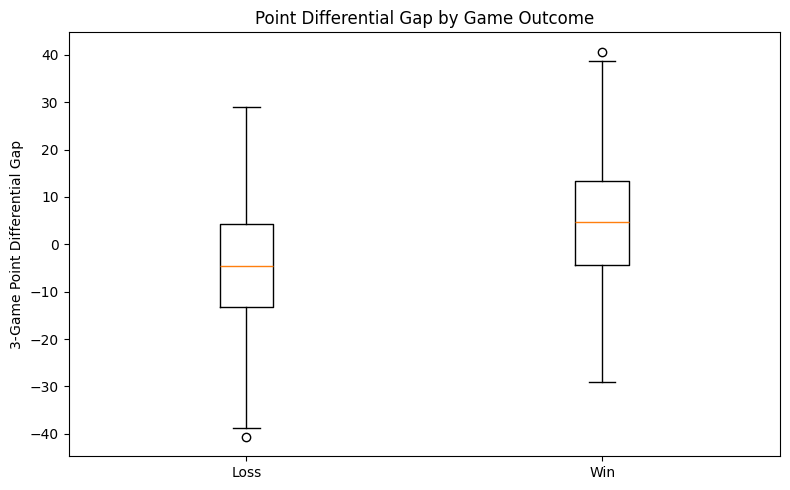

,outcome,mean_point_diff_gap_3,median_point_diff_gap_3
0,Loss,-4.248156,-4.666667
1,Win,4.265320,4.666667


In [22]:
pd_losses = eda.loc[eda["win"] == 0, "point_diff_gap_3"]
pd_wins = eda.loc[eda["win"] == 1, "point_diff_gap_3"]

plt.figure(figsize=(8, 5))
plt.boxplot([pd_losses, pd_wins], tick_labels=["Loss", "Win"])
plt.ylabel("3-Game Point Differential Gap")
plt.title("Point Differential Gap by Game Outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "point_diff_gap_by_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

pointdiff_outcome_summary = pd.DataFrame({
    "outcome": ["Loss", "Win"],
    "mean_point_diff_gap_3": [pd_losses.mean(), pd_wins.mean()],
    "median_point_diff_gap_3": [pd_losses.median(), pd_wins.median()]
})

pointdiff_outcome_summary.to_csv(TAB_DIR / "point_diff_gap_outcome_summary.csv", index=False)
pointdiff_outcome_summary

In [23]:
corr_cols = [
    "win",
    "is_home",
    "rest_days",
    "rolling_win_pct_3",
    "opp_rolling_win_pct_3",
    "win_pct_diff_3",
    "rolling_off_epa_3",
    "opp_rolling_off_epa_3",
    "epa_diff_3",
    "rolling_point_diff_3",
    "opp_rolling_point_diff_3",
    "point_diff_gap_3"
]

corr_matrix = eda[corr_cols].corr()
corr_matrix.to_csv(TAB_DIR / "correlation_matrix.csv")
corr_matrix

,win,is_home,rest_days,rolling_win_pct_3,opp_rolling_win_pct_3,win_pct_diff_3,rolling_off_epa_3,opp_rolling_off_epa_3,epa_diff_3,rolling_point_diff_3,opp_rolling_point_diff_3,point_diff_gap_3
win,1.000000,0.078629,0.001383,0.220870,-0.220882,0.310942,0.200641,-0.202382,0.283726,0.223642,-0.223784,0.314939
is_home,0.078629,1.000000,-0.029496,-0.001013,0.001013,-0.001426,-0.003077,0.003077,-0.004333,-0.019355,0.019355,-0.027248
rest_days,0.001383,-0.029496,1.000000,0.001129,-0.046209,0.033321,0.005048,-0.034050,0.027525,0.002117,-0.040371,0.029907
rolling_win_pct_3,0.220870,-0.001013,0.001129,1.000000,-0.009174,0.710343,0.590334,0.001474,0.414555,0.820840,0.008626,0.571709
opp_rolling_win_pct_3,-0.220882,0.001013,-0.046209,-0.009174,1.000000,-0.710343,0.001474,0.590334,-0.414555,0.008626,0.820840,-0.571709
win_pct_diff_3,0.310942,-0.001426,0.033321,0.710343,-0.710343,1.000000,0.414490,-0.414490,0.583599,0.571705,-0.571705,0.804836
rolling_off_epa_3,0.200641,-0.003077,0.005048,0.590334,0.001474,0.414490,1.000000,-0.008858,0.710232,0.728811,0.002852,0.510996
opp_rolling_off_epa_3,-0.202382,0.003077,-0.034050,0.001474,0.590334,-0.414490,-0.008858,1.000000,-0.710232,0.002852,0.728811,-0.510996
epa_diff_3,0.283726,-0.004333,0.027525,0.414555,-0.414555,0.583599,0.710232,-0.710232,1.000000,0.511072,-0.511072,0.719477
rolling_point_diff_3,0.223642,-0.019355,0.002117,0.820840,0.008626,0.571705,0.728811,0.002852,0.511072,1.000000,-0.009160,0.710338


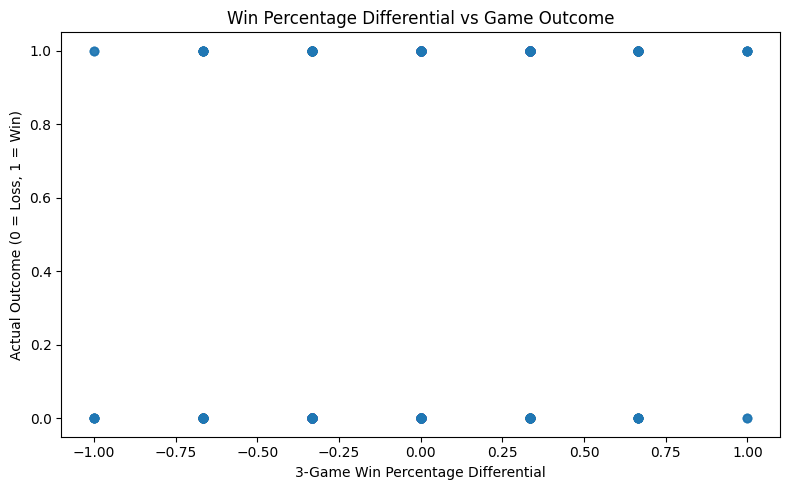

In [24]:
sampled = eda[["win_pct_diff_3", "win"]].copy()

plt.figure(figsize=(8, 5))
plt.scatter(sampled["win_pct_diff_3"], sampled["win"], alpha=0.25)
plt.xlabel("3-Game Win Percentage Differential")
plt.ylabel("Actual Outcome (0 = Loss, 1 = Win)")
plt.title("Win Percentage Differential vs Game Outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "win_pct_diff_vs_outcome_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
eda_findings = pd.DataFrame({
    "findings": [
        "Home teams win more often than away teams",
        "Teams with a more positive recent win percentage differential tend to win more often",
        "EPA differential showed separation between wins and losses",
        "Point differential gap shows directional separation but did not improve the final best model",
        "The strongest final predictor was recent win percentage differential"
    ]
})

eda_findings.to_csv(TAB_DIR / "eda_key_findings.csv", index=False)
eda_findings

,findings
0,Home teams win more often than away teams
1,Teams with a more positive recent win percenta...
2,EPA differential showed separation between win...
3,Point differential gap shows directional separ...
4,The strongest final predictor was recent win p...
